In [38]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# QUESTIONS 
Plot distance vs fare (scatter plot).

Plot passengers by ticket type (bar chart).

Plot daily revenue trend (line chart).

Plot top 10 stations by passenger traffic

# FIRST WE WILL LOAD THE DATASET

In [39]:
Data = r"C:\Users\HP VICTUS\OneDrive\Desktop\delhi metro sales\delhi_metro_updated.csv"
df = pd.read_csv(Data)
df.head()
	

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,NaN,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak


# WE FIND MORE INFORMATION ABOUT THE DATA TO UNDERSTAND IT 

In [40]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TripID              150000 non-null  int64  
 1   Date                150000 non-null  object 
 2   From_Station        150000 non-null  object 
 3   To_Station          150000 non-null  object 
 4   Distance_km         150000 non-null  float64
 5   Fare                150000 non-null  float64
 6   Cost_per_passenger  150000 non-null  float64
 7   Passengers          148500 non-null  float64
 8   Ticket_Type         148500 non-null  object 
 9   Remarks             123743 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 11.4+ MB


In [41]:
missing_data = df[["Ticket_Type", "Passengers", "Remarks"]]

print(missing_data)

         Ticket_Type  Passengers      Remarks
0         Smart Card        13.0  maintenance
1       Tourist Card        15.0  maintenance
2             Single         9.0     off-peak
3                NaN        27.0  maintenance
4             Single        23.0     off-peak
...              ...         ...          ...
149995  Tourist Card        28.0         peak
149996  Tourist Card        21.0     off-peak
149997    Smart Card        18.0     festival
149998        Single        18.0      weekend
149999        Single        20.0          NaN

[150000 rows x 3 columns]


# TO FIND THE THE TICKET TYPES

In [42]:
print(df["Ticket_Type"].value_counts())

Ticket_Type
Tourist Card    59193
Single          37341
Smart Card      37244
Return          14722
Name: count, dtype: int64


# TO RECTIFY THE UNEVEN SPACE 

In [43]:
df["From_Station"].str.strip()

0                  Inderlok
1                Model Town
2             Kashmere Gate
3             Chandni Chowk
4               Rajiv Chowk
                ...        
149995          KIRTI NAGAR
149996           Model Town
149997    Noida City Centre
149998      Barakhamba Road
149999            New Delhi
Name: From_Station, Length: 150000, dtype: object

# DELHI METRO DIDN'T USUALLY PROVIDE THE RETURN TICKET 

In [44]:
mask = (df.index < 149999) & (df["Ticket_Type"].astype(str).str.strip().str.lower() == "return")

df.loc[mask, "Ticket_Type"] = "Tourist Card"


In [45]:
print(df["Ticket_Type"].value_counts())

Ticket_Type
Tourist Card    73915
Single          37341
Smart Card      37244
Name: count, dtype: int64


<Axes: xlabel='Ticket_Type', ylabel='count'>

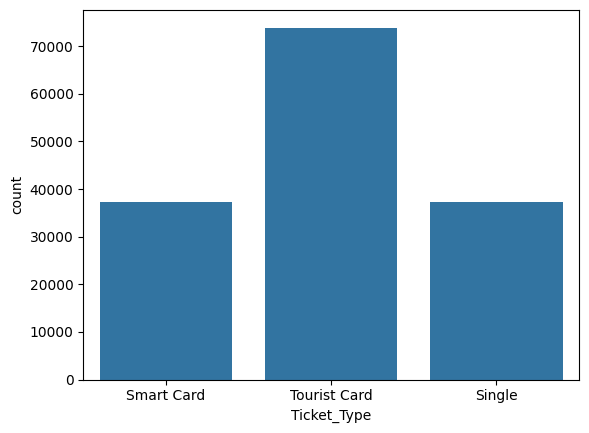

In [46]:
sns.countplot(x = "Ticket_Type", data = df)

# TO FIND HOW MANY NAN VALUE WE HAVE IN Ticket_Type

In [47]:
print(df["Ticket_Type"].value_counts(dropna=False))

Ticket_Type
Tourist Card    73915
Single          37341
Smart Card      37244
NaN              1500
Name: count, dtype: int64


In [48]:
print('\nremarks blank count', (df["Remarks"] == '').sum())
print('\npassengers null count', df["Passengers"].isna().sum())


remarks blank count 0

passengers null count 1500


In [49]:
print(df["From_Station"].sample(10))

71753                 Model Town
101295                  Inderlok
636                Chandni Chowk
44376          Noida City Centre
110549     CENTRAL SECRETARIAT  
59064          Noida City Centre
39764             Kalkaji Mandir
101624                 Inderlok 
116840                Old Delhi 
108882                     AIIMS
Name: From_Station, dtype: object


# TRIMMING WHITESPACE AND FIXING CASE OF From_Station

In [50]:
df["From_Station"] = df["From_Station"].astype(str).str.strip().str.title()
print(df["From_Station"].sample(10))

104610          Kashmere Gate
112666             Model Town
96909          Janakpuri West
114091         Janakpuri West
4689                Hauz Khas
24136             Mandi House
27372     Central Secretariat
132443              Old Delhi
56007          Rajouri Garden
145064          Chandni Chowk
Name: From_Station, dtype: object


# LET'S HANDLE THE NA STRING IN DATA

In [51]:
df["Ticket_Type"] = df["Ticket_Type"].replace('NA', np.nan)
print('null value in Ticket_Type:', (df["Ticket_Type"].isna().sum()))

null value in Ticket_Type: 1500


# NOW LETS JUST REPLACE THE NULL VALUES

In [52]:
mode_ticket = df["Ticket_Type"].mode(dropna=True)[0]
print('mode ticket type:', mode_ticket)

df["Ticket_Type"] = df["Ticket_Type"].fillna(mode_ticket)
print(df["Ticket_Type"].isna().sum())

mode ticket type: Tourist Card
0


# NOW WE HAVE TO TACKLE THE BLANK VALUES IN REMARKS

In [53]:
df["Remarks"] = df["Remarks"].replace('', np.nan)
print('blank value in Remarks:', (df["Remarks"].isna().sum()))

blank value in Remarks: 26257


# LET'S HANDLE THE MISSING VALUE OF PASSENGERS 

In [54]:
median_pass = int(df['Passengers'].median(skipna=True))
print('Median passengers:', median_pass)

Median passengers: 20


In [55]:
df['Passengers'] = df['Passengers'].fillna(median_pass)
print('Passengers nulls after replacing:', df['Passengers'].isna().sum()) # to check

Passengers nulls after replacing: 0


# PASSENGER'S BY TICKET_TYPE

In [56]:
passengers_by_ticket = df.groupby('Ticket_Type')['Passengers'].sum().sort_values(ascending=False)

print(passengers_by_ticket)

Ticket_Type
Tourist Card    1507863.0
Single           747171.0
Smart Card       745489.0
Name: Passengers, dtype: float64


creating a profit column

In [57]:
df['Profit_per_passenger'] = df['Fare'] - df['Cost_per_passenger']
df['Profit'] = df['Profit_per_passenger'] * df['Passengers']

In [58]:
print(df[['Fare','Cost_per_passenger','Passengers','Profit_per_passenger','Profit']].head())
print('\nTotal profit across dataset:', df['Profit'].sum()) # sometimes we also get loss

     Fare  Cost_per_passenger  Passengers  Profit_per_passenger   Profit
0   77.99               18.27        13.0                 59.72   776.36
1   35.89               83.71        15.0                -47.82  -717.30
2   64.35               43.70         9.0                 20.65   185.85
3  144.13               14.98        27.0                129.15  3487.05
4  104.96               83.84        23.0                 21.12   485.76

Total profit across dataset: 127941908.47999999


# CLEANED DATA CSV FILE

In [59]:
cleaned_path = 'delhi_metro_cleaned_Dataset.csv' #CLEANED DATA CSV FILE 
df.to_csv(cleaned_path, index=False)
print('Saved cleaned CSV to', cleaned_path)

Saved cleaned CSV to delhi_metro_cleaned_Dataset.csv


# NOW LETS JUST START PLOTTING

# TOP 10 STATIONS BY THE NUMBER OF TRIPS

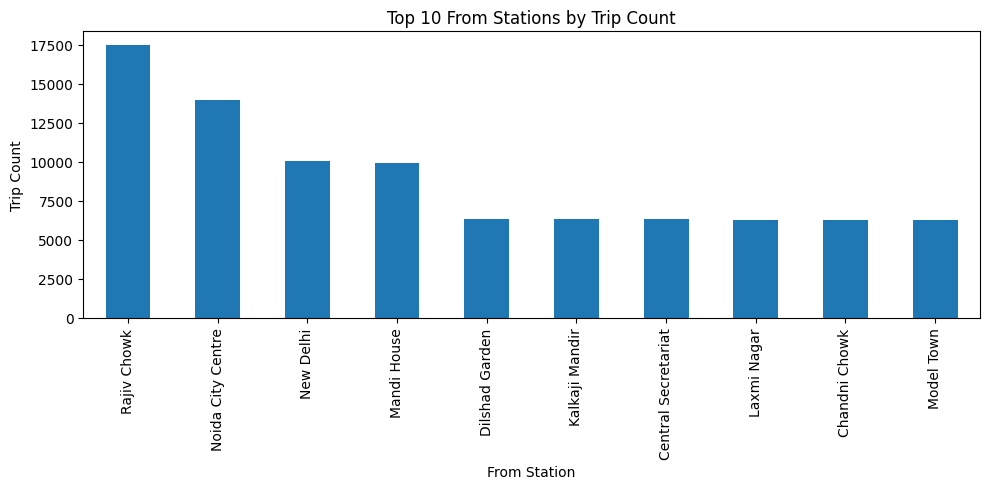

In [60]:
plt.figure(figsize=(10,5))
station_counts = df['From_Station'].value_counts().nlargest(10)
station_counts.plot(kind='bar')
plt.title('Top 10 From Stations by Trip Count')
plt.xlabel('From Station')
plt.ylabel('Trip Count')
plt.tight_layout()
plt.show()

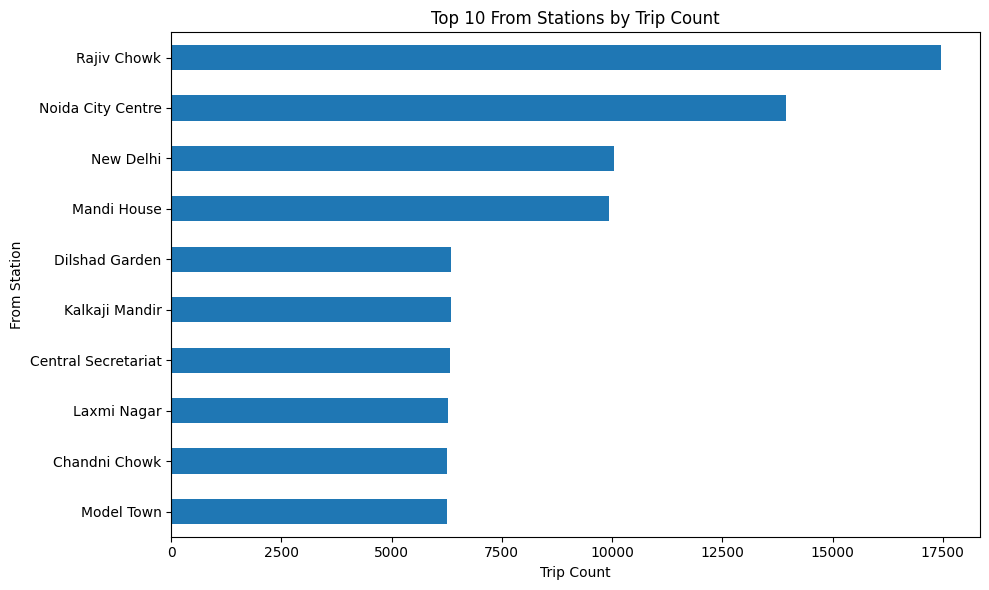

In [61]:
plt.figure(figsize=(10,6))
station_counts = df['From_Station'].value_counts().nlargest(10)

station_counts.plot(kind='barh')
plt.title('Top 10 From Stations by Trip Count')
plt.xlabel('Trip Count')
plt.ylabel('From Station')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# DISTRIBUTION OF FARE VIA BOXPLOT

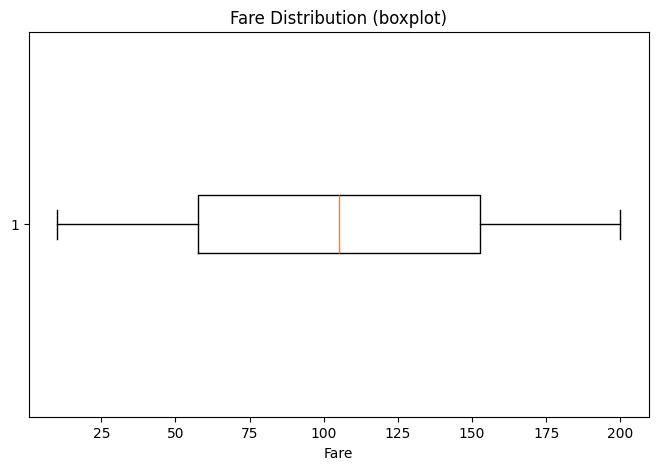

In [62]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Fare'].dropna(), vert=False)
plt.title('Fare Distribution (boxplot)')
plt.xlabel('Fare')
plt.show()

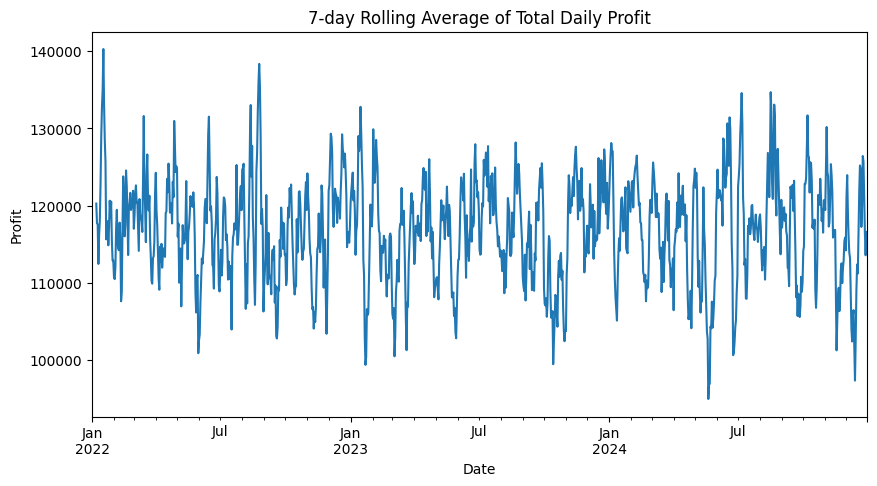

In [63]:
plt.figure(figsize=(10,5))
df['Date'] = pd.to_datetime(df['Date'])
daily = df.groupby('Date')['Profit'].sum().sort_index()
daily.rolling(window=7).mean().plot()
plt.title('7-day Rolling Average of Total Daily Profit')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.show()

# PLOTTING OF DISTANCE VS FARE ( SCATTER PLOT)

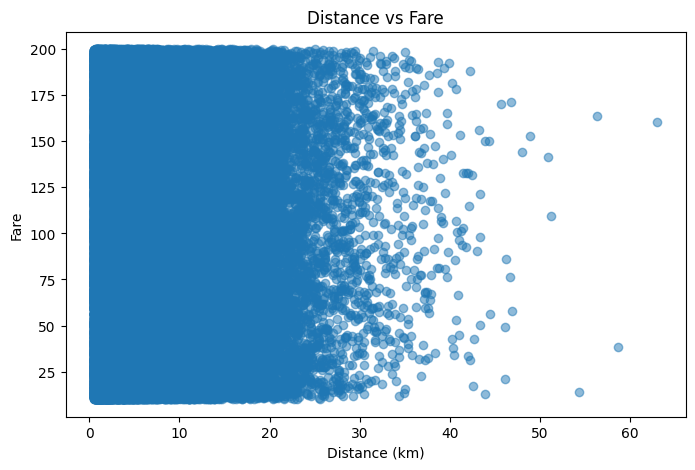

In [64]:
plt.figure(figsize=(8,5))
plt.scatter(df['Distance_km'], df['Fare'], alpha=0.5)

plt.title('Distance vs Fare')
plt.xlabel('Distance (km)')
plt.ylabel('Fare')

plt.show()

# PASSENGER BY TICKET TYPE

In [65]:
df.head()

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks,Profit_per_passenger,Profit
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance,59.72,776.36
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance,-47.82,-717.30
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak,20.65,185.85
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,Tourist Card,maintenance,129.15,3487.05
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak,21.12,485.76


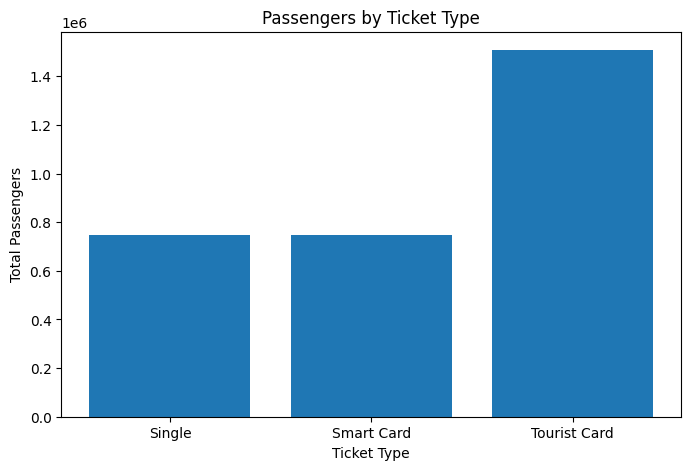

In [66]:
passengers_by_ticket = df.groupby('Ticket_Type')['Passengers'].sum()

plt.figure(figsize=(8,5))
plt.bar(passengers_by_ticket.index, passengers_by_ticket.values)

plt.title('Passengers by Ticket Type')
plt.xlabel('Ticket Type')
plt.ylabel('Total Passengers')

plt.show()

# DAILY PROFIT TREND

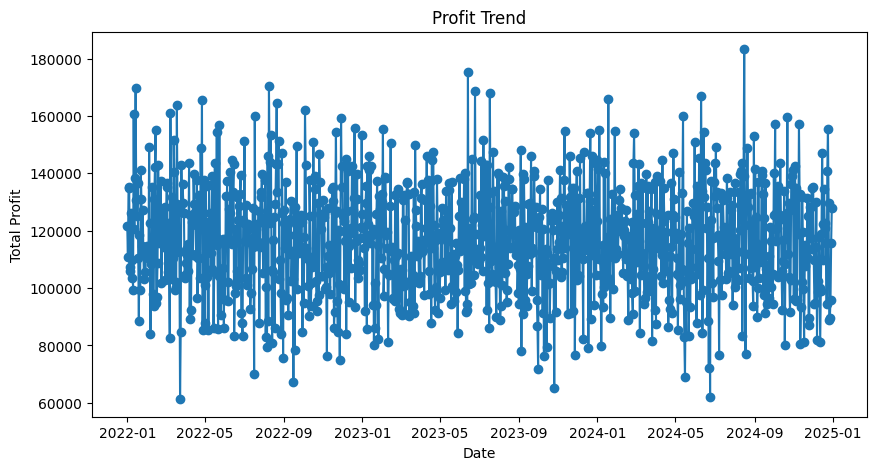

In [67]:
df['Date'] = pd.to_datetime(df['Date'])

# calculate daily profit
daily_profit = df.groupby('Date')['Profit'].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_profit.index, daily_profit.values, marker='o')

plt.title('Profit Trend')
plt.xlabel('Date')
plt.ylabel('Total Profit')

plt.show()

In [68]:
df.sample(10)

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks,Profit_per_passenger,Profit
37687,98261,2022-06-18,Inderlok,Barakhamba Road,2.20,10.81,71.43,24.0,Smart Card,off-peak,-60.62,-1454.88
78394,67058,2022-12-09,Noida City Centre,Kirti Nagar,11.40,129.59,54.92,21.0,Tourist Card,festival,74.67,1568.07
7974,62315,2022-04-06,Rajiv Chowk,Inderlok,11.40,46.85,32.26,12.0,Tourist Card,off-peak,14.59,175.08
5870,40499,2024-04-05,Inderlok,Chandni Chowk,11.34,188.08,93.56,20.0,Single,off-peak,94.52,1890.40
39035,42779,2023-11-11,Mandi House,Rajouri Garden,2.83,184.08,65.59,27.0,Single,off-peak,118.49,3199.23
42717,143995,2023-11-12,Rajouri Garden,Inderlok,6.53,130.16,55.09,26.0,Smart Card,maintenance,75.07,1951.82
122121,33961,2022-07-19,New Delhi,Janakpuri West,7.22,17.72,97.24,18.0,Single,off-peak,-79.52,-1431.36
138703,102209,2022-08-05,Laxmi Nagar,New Delhi,6.42,37.85,118.55,19.0,Tourist Card,festival,-80.70,-1533.30
24266,79384,2022-12-25,Rajiv Chowk,Kirti Nagar,1.03,45.87,40.52,19.0,Single,NaN,5.35,101.65
65522,129721,2023-02-13,Chandni Chowk,Hauz Khas,3.26,189.95,38.37,21.0,Tourist Card,festival,151.58,3183.18


# TOP 10 PROFITABLE routes

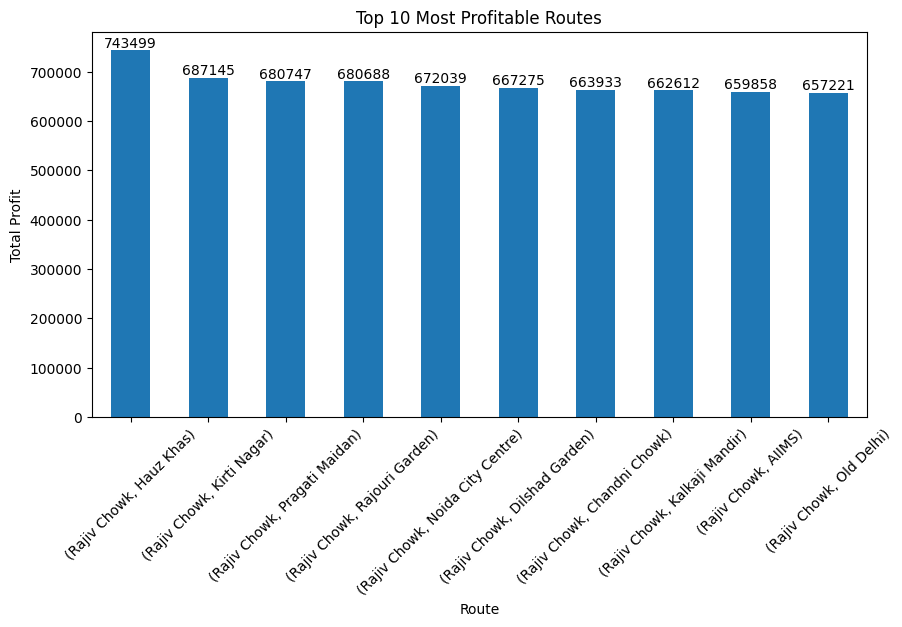

In [70]:
route_profit = df.groupby(['From_Station','To_Station'])['Profit'].sum().sort_values(ascending=False).head(10)

ax = route_profit.plot(kind='bar', figsize=(10,5))

for container in ax.containers:
    ax.bar_label(container)

plt.title('Top 10 Most Profitable Routes')
plt.xlabel('Route')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)

plt.show()